# *G* por balanza de Cavendish

Análisis no paramétrico, **seleccionable entre 3 mediciones** (26 / 28 / 30). Elegí cuál en la
celda de configuración (`MEDICION`). $G=\kappa\,\Delta\theta/\tau_1$, con $\kappa=I\,\omega_0^2$ y
$\omega_0^2=\omega_d^2+\beta^2$ (se corrige el amortiguamiento).

| med | κ se obtiene de… | Δθ |
|---|---|---|
| **26** | período del tramo **sin imanes** (T2), solo mínimos (máximos cortados). β≈0 | T3(imán,sin masa) vs T4(imán,con masa) |
| **28** | **ajuste de la 27** como seno amortiguado (κ y β) | T1(sin masa) vs T2(con masa, 9.5 cm) |
| **30** | período propio (mín/máx/cruces) **+ ajuste** del ring-down (β) | T3 / T4 / T5 (con retorno) |

## ⚙️ Configuración — elegí la medición y editá las ventanas acá

In [182]:
%matplotlib inline
import os, glob, re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "legend.frameon": False, "legend.fontsize": 9, "lines.linewidth": 1.5,
})
C_SM, C_CM, C_R = "#2563eb", "#dc2626", "#16a34a"   # sin masa / con masa / retorno

# ============ constantes físicas (comunes) ============
BASE = Path(r"C:\Users\lenny\OneDrive\Documents\FISICA\LABO 4\labo-4-2026\CAVENDISH\Datos")
OUT  = Path(r"C:\Users\lenny\OneDrive\Documents\FISICA\LABO 4\labo-4-2026\CAVENDISH\Análisis")
FIGS = OUT / "figuras"; FIGS.mkdir(exist_ok=True)
CACHE = OUT / "_cache"; CACHE.mkdir(exist_ok=True)
USAR_CACHE = True
G_CODATA = 6.674e-11
FACTOR_ESPEJO = 2.0
LX_P, LY_P, LZ_P = 14.04e-2, 3.48e-2, 7e-2
R_BRAZO = 37e-2
MASA_PRISMA = 3.75
DENS_P = MASA_PRISMA / (LX_P * LY_P * LZ_P)
R_BOLA = 5.3e-2; M_BOLA = 4.6
N_GL = 12; INCLUIR_BRAZO_LEJANO = False
SEP_MIN_S = 60.0; VENTANA_EXTREMO_S = 5.0
SIG_D = 0.7e-2; SIG_R = 0.5e-2; SIG_MB = 0.05

# ===================== ELEGIR MEDICIÓN =====================
MEDICION = "medicion30"      # <<<<<<  "medicion26" | "medicion28" | "medicion30"

MEDICIONES = {
  "medicion26": dict(
      d_cm_cm=8.0e-2, t0_plot=0,
      # Los imanes SUBEN κ (cambian la frecu8ncia: T~965 s sin imán -> ~525 s con imán).
      # Para el Δθ CON imán se usa la κ CON imán (consistente). La sin imán queda de referencia.
      kappa_metodos=[
          dict(label="período mín (T3 CON imán)", tipo="periodo", win=(8900, 11400), pico="min"),
          dict(label="período mín (T2 sin imán)", tipo="periodo", win=(2204, 7862),  pico="min"),
      ],
      usar_beta_de=None, kappa_elegido="período mín (T3 CON imán)",
      comparar_iman=dict(sin_iman=(2204, 7862), con_iman=(8900, 11400), pico="min"),
      # Δθ CON imán, salteando los transitorios de asentamiento (los imanes apagan la gran oscilación).
      sin_masa=dict(win=(8900, 11400),  pico="max", desde=1, hasta=4),   # T3 asentado, imán sin masa
      con_masa=dict(win=(11600, 15000), pico="max", desde=1, hasta=5),   # T4 asentado, imán con masa (~8 cm)
      sin_masa_2=None,
      nota="CON imán (T3/T4 asentados). κ CON imán (consistente con Δθ con imán; los imanes suben κ). T4 chocó (7.5->8.5)."),
  "medicion28": dict(
      d_cm_cm=9.5e-2, t0_plot=0,
      kappa_metodos=[
          dict(label="ajuste 27 (seno amort.)", tipo="ajuste", fuente="medicion27", win=(0, 1500)),
      ],
      usar_beta_de="ajuste 27 (seno amort.)", kappa_elegido="ajuste 27 (seno amort.)",
      sin_masa=dict(win=(200, 3047),  pico="max", desde=2, hasta=8),     # T1 imán sin masa
      con_masa=dict(win=(3577, 9030), pico="max", desde=6, hasta=11),    # T2 imán con masa 9.5 cm
      sin_masa_2=None,
      nota="κ del ajuste de la 27 (mismo setup de la tarde). Sin tramo de retorno."),
  "medicion30": dict(
      d_cm_cm=6.0e-2, t0_plot=5580,
      kappa_metodos=[
          dict(label="período mín",      tipo="periodo", win=(5980, 8919), win2=(12803, 16441), pico="min"),
          dict(label="período máx",      tipo="periodo", win=(5980, 8919), win2=(12803, 16441), pico="max"),
          dict(label="período cruces",   tipo="periodo", win=(5980, 8919), win2=(12803, 16441), pico="cruces"),
          dict(label="ajuste ring-down", tipo="ajuste",  fuente="medicion30", win=(5980, 8919)),
      ],
      usar_beta_de="ajuste ring-down", kappa_elegido="ajuste ring-down",
      sin_masa=dict(win=(5980, 8919),   pico="max", desde=1, hasta=9),   # T3 sin masa
      con_masa=dict(win=(8919, 12803),  pico="max", desde=2, hasta=11),  # T4 con masa 6 cm
      sin_masa_2=None,  # PRIMER PAR: solo T3 sin masa -> T4 con masa (sin retorno)
      nota="con imán en todos los tramos; κ período propio + ajuste (β)."),
}
cfg = MEDICIONES[MEDICION]
print("Medición elegida:", MEDICION, "|", cfg["nota"])

Medición elegida: medicion30 | con imán en todos los tramos; κ período propio + ajuste (β).


In [183]:
# =================== Lectura de datos ===================
def parse_meta(path):
    d = {}
    for ln in Path(path).read_text(encoding="utf-8", errors="replace").splitlines():
        ln = ln.strip()
        if "\t" in ln and not ln.startswith("#"):
            k, v = ln.split("\t", 1); d[k] = v
    return d

def load_medicion(nombre, verbose=False):
    """Concatena chunks -> (t, x_mm, y_mm). Robusta a archivos malos; cose reinicios; cachea."""
    carpeta = BASE / nombre
    metas = glob.glob(str(carpeta / "*_meta.txt")); meta = parse_meta(metas[0]) if metas else {}
    L_mm = float(meta.get("distancia_a_la_pantalla (cm)", "nan")) * 10.0
    events = sorted(float(v) for k, v in meta.items() if re.match(r"masa_\d+_s$", k))
    cache = CACHE / f"{nombre}.npy"
    if USAR_CACHE and cache.exists():
        d = np.load(cache); t, x, y = d[0], d[1], d[2]
    else:
        archivos = sorted(glob.glob(str(carpeta / "*_[0-9][0-9][0-9][0-9].txt")),
                          key=lambda f: int(re.search(r"_(\d+)\.txt$", f).group(1)))
        if not archivos: raise FileNotFoundError(f"No hay chunks en {carpeta}")
        partes, malos = [], 0
        for f in archivos:
            try: a = pd.read_csv(f, sep="\t", header=None, dtype=float).values
            except Exception:
                try: a = np.atleast_2d(np.loadtxt(f))
                except Exception: malos += 1; continue
            if a.size and a.shape[1] >= 3: partes.append(np.atleast_2d(a[:, :3]))
            else: malos += 1
        datos = np.concatenate(partes, axis=0)
        t, x, y = datos[:, 0].copy(), datos[:, 1].copy(), datos[:, 2].copy()
        dd = np.diff(t); dt_med = np.median(dd[dd > 0]); saltos = np.flatnonzero(dd < 0)
        for j in saltos: t[j + 1:] += (t[j] - t[j + 1] + dt_med)
        np.save(cache, np.vstack([t, x, y]))
    return dict(nombre=nombre, t=t, x_mm=x, y_mm=y, L_mm=L_mm, events=events, meta=meta)

def a_rad(v_mm, L_mm):
    return np.arctan(v_mm / L_mm) / FACTOR_ESPEJO
print("I/O listo.")

I/O listo.


In [184]:
# =================== No paramétrico ===================
def cruces(t, x, nivel, sep_min_s=SEP_MIN_S):
    arr = x > nivel; i = np.flatnonzero(arr[1:] != arr[:-1])
    if len(i) == 0: return np.array([]), np.array([], dtype=int)
    grupos = np.split(np.arange(len(i)), np.flatnonzero(np.diff(t[i]) > sep_min_s) + 1)
    tc, dc = [], []
    for g in grupos:
        if arr[i[g[0]]] == arr[i[g[-1]] + 1]: continue
        tc.append(float(t[i[g]].mean())); dc.append(+1 if arr[i[g[-1]] + 1] else -1)
    return np.array(tc), np.array(dc, dtype=int)

def extremos(ts, xs, t_cr, d_cr, v=VENTANA_EXTREMO_S):
    te, xe, tipo = [], [], []
    for i in range(len(t_cr) - 1):
        a, b = t_cr[i], t_cr[i + 1]; es_max = (d_cr[i] == +1); w = (ts >= a) & (ts <= b)
        if w.sum() < 10: continue
        tw, xw = ts[w], xs[w]; tg = np.arange(a + v, b - v + 1e-9, v)
        if len(tg) < 1:
            j = int(np.argmax(xw) if es_max else np.argmin(xw)); te.append(float(tw[j])); xe.append(float(xw[j]))
        else:
            md_ = np.array([np.median(xw[np.abs(tw - g) <= v]) for g in tg])
            j = int(np.argmax(md_) if es_max else np.argmin(md_)); te.append(float(tg[j])); xe.append(float(md_[j]))
        tipo.append(+1 if es_max else -1)
    return np.array(te), np.array(xe), np.array(tipo, dtype=int)

def extremos_tramo(t, th, win):
    m = (t >= win[0]) & (t <= win[1]); ts, xs = t[m], th[m]
    tc, dc = cruces(ts, xs, float(np.median(xs)))
    return extremos(ts, xs, tc, dc)

def picos(te, xe, tipo, kind):
    m = tipo == (+1 if kind == "max" else -1); return te[m], xe[m]

def intervalo_por_picos(te, tipo, kind, desde, hasta):
    tk = picos(te, te, tipo, kind)[0]
    if len(tk) < hasta: return (tk[0] if len(tk) else np.nan), (tk[-1] if len(tk) else np.nan), len(tk)
    return float(tk[desde - 1]), float(tk[hasta - 1]), len(tk)

def periodo_tramo(t, th, win, modo="min"):
    m = (t >= win[0]) & (t <= win[1]); ts, xs = t[m], th[m]
    tc, dc = cruces(ts, xs, float(np.median(xs)))
    if modo == "cruces":
        seps = np.concatenate([np.diff(tc[dc > 0]), np.diff(tc[dc < 0])])
    else:
        te, xe, tipo = extremos(ts, xs, tc, dc)
        sd = lambda k: np.diff(picos(te, te, tipo, k)[0])
        seps = np.concatenate([sd("min"), sd("max")]) if modo == "ambos" else sd(modo)
    if len(seps) == 0: return np.nan, np.nan, 0
    return float(np.median(seps)), (float(np.std(seps)) if len(seps) > 1 else np.nan), len(seps)

def midlines(te, xe, t_lo, t_hi):
    m = (te >= t_lo - 1e-6) & (te <= t_hi + 1e-6); tu, xu = te[m], xe[m]
    if len(xu) < 2: return np.array([]), np.array([])
    return 0.5 * (tu[1:] + tu[:-1]), 0.5 * (xu[1:] + xu[:-1])

def equilibrio_detrend(te, xe, t_lo, t_hi):
    """Equilibrio = midlines al centro quitando deriva lineal; error = SEM del residuo."""
    tm, mids = midlines(te, xe, t_lo, t_hi)
    if len(mids) < 2: return (float(mids.mean()) if len(mids) else np.nan), np.nan, 0.0, tm, mids
    if len(mids) >= 3:
        p = np.polyfit(tm, mids, 1); r = mids - np.polyval(p, tm)
        return float(np.polyval(p, tm.mean())), float(r.std(ddof=1)/np.sqrt(len(mids))), float(p[0]), tm, mids
    return float(mids.mean()), float(mids.std(ddof=1)/np.sqrt(len(mids))), 0.0, tm, mids
print("No paramétrico listo.")

No paramétrico listo.


In [185]:
# =================== Ajuste amortiguado + búsqueda de ventana ===================
def modelo_amortiguado(t, eq, A, beta, wd, phi):
    return eq + A * np.exp(-beta * t) * np.cos(wd * t + phi)

def ajustar_amortiguado(t, th, win):
    m = (t >= win[0]) & (t <= win[1]); tt = t[m] - t[m][0]; xx = th[m]
    eq0 = np.mean(xx); A0 = (xx.max() - xx.min()) / 2
    s = np.sign(xx - eq0); cr = tt[np.flatnonzero((s[:-1] < 0) & (s[1:] >= 0))]
    wd0 = 2 * np.pi / (np.median(np.diff(cr)) if len(cr) > 1 else tt[-1] / 4)
    h = len(xx) // 2
    Ai = (xx[:h].max() - xx[:h].min()) / 2; Af = (xx[h:].max() - xx[h:].min()) / 2
    beta0 = max(1e-5, np.log(max(Ai, 1e-9) / max(Af, 1e-9)) / (tt[-1] / 2))
    p0 = [eq0, A0, beta0, wd0, 0.0]
    bnd = ([eq0 - 1, 0, 0, wd0 * 0.5, -2*np.pi], [eq0 + 1, 5*A0, 1e-1, wd0 * 1.5, 2*np.pi])
    popt, _ = curve_fit(modelo_amortiguado, tt, xx, p0=p0, bounds=bnd, maxfev=200000)
    eq, A, beta, wd, phi = popt; resid = xx - modelo_amortiguado(tt, *popt)
    return dict(eq=eq, A=A, beta=beta, wd=wd, w0=np.hypot(wd, beta), rms=float(np.sqrt(np.mean(resid**2))),
                win=win, t0=t[m][0], tt=tt, xx=xx, fit=modelo_amortiguado(tt, *popt), resid=resid)

def mejor_ventana_ajuste(t, th, win0, n_pasos=10, frac_fin=0.92):
    a0, b0 = win0; b = a0 + frac_fin * (b0 - a0); paso = (b - a0) / (n_pasos + 4); cand = []
    for k in range(n_pasos):
        a = a0 + k * paso
        if b - a < 4 * paso: break
        try: f = ajustar_amortiguado(t, th, (a, b)); cand.append((f["rms"] / f["A"], f))
        except Exception: pass
    cand.sort(key=lambda z: z[0]); return cand[0][1]

# =================== Inercia, torque, propagación ===================
def I_colgado():
    m = DENS_P * LX_P * LY_P * LZ_P
    return 2 * (m / 12 * (LX_P**2 + LY_P**2) + m * R_BRAZO**2)
def kappa_de_w0(w0): return I_colgado() * w0**2

def torque_z(phi, R_arm, lp, dens_p, fuente, M, Gc, n_gl=N_GL):
    nodes, w = np.polynomial.legendre.leggauss(n_gl)
    hx, hy, hz = lp[0]/2, lp[1]/2, lp[2]/2
    U, V, Wz = np.meshgrid(hx*nodes, hy*nodes, hz*nodes, indexing="ij")
    WT = (w*hx)[:, None, None] * (w*hy)[None, :, None] * (w*hz)[None, None, :]
    c, s = np.cos(phi), np.sin(phi)
    xp = (U + R_arm)*c - V*s; yp = (U + R_arm)*s + V*c; zp = Wz
    xc, yc, zc = fuente; dx, dy, dz = xc - xp, yc - yp, zc - zp
    r = np.sqrt(dx*dx + dy*dy + dz*dz); f = Gc * M / r**3
    return float(np.sum((xp*(f*dy) - yp*(f*dx)) * dens_p * WT))

def tau_por_G(dtheta, d, R_arm=R_BRAZO, M=M_BOLA, ambos=INCLUIR_BRAZO_LEJANO):
    lp = (LX_P, LY_P, LZ_P); fuente = (R_arm, d, 0.0)
    tau = torque_z(dtheta, R_arm, lp, DENS_P, fuente, M, 1.0)
    if ambos: tau += torque_z(dtheta + np.pi, R_arm, lp, DENS_P, fuente, M, 1.0)
    return tau

def G_de(kappa, dtheta, d): return kappa * abs(dtheta) / tau_por_G(abs(dtheta), d)

def propagar_G(kappa, dtheta, d, sig):
    base = dict(kappa=kappa, dtheta=abs(dtheta), d=d)
    f = lambda **kw: kw["kappa"] * kw["dtheta"] / tau_por_G(kw["dtheta"], kw["d"])
    G0 = f(**base); var = 0.0; contrib = {}
    for k, s in sig.items():
        if not s or base[k] == 0: contrib[k] = 0.0; continue
        hh = abs(base[k]) * 1e-4
        up = dict(base); up[k] += hh; dn = dict(base); dn[k] -= hh
        ci = ((f(**up) - f(**dn)) / (2*hh) * s)**2; contrib[k] = ci; var += ci
    return G0, np.sqrt(var), {k: (100*v/var if var > 0 else 0.0) for k, v in contrib.items()}
print(f"I_colgado = {I_colgado():.4f} kg·m²")

I_colgado = 1.0398 kg·m²


## 1) Señal y tramos

medicion30: 4.57 h  eventos=[5970, 5980, 8919, 12803] s


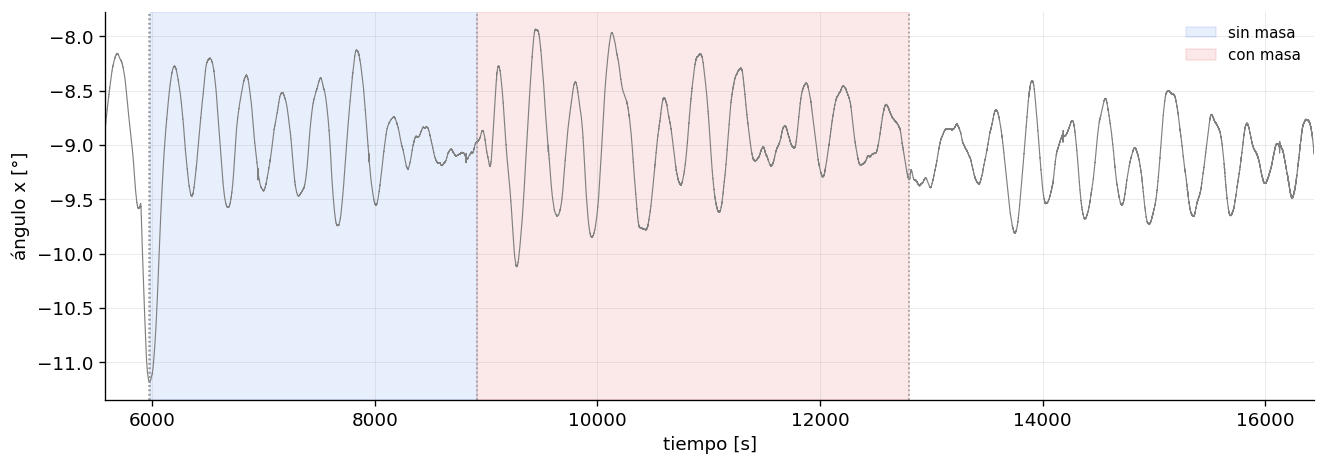

In [186]:
m = load_medicion(MEDICION); th = a_rad(m["x_mm"], m["L_mm"]); t = m["t"]; ev = m["events"]
T0 = cfg.get("t0_plot", 0); mv = t >= T0
print(f"{MEDICION}: {t[-1]/3600:.2f} h  eventos={[round(e) for e in ev]} s")
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(t[mv], np.degrees(th[mv]), lw=0.7, color="0.5")
def shade(w, c, lab):
    if w: ax.axvspan(w["win"][0], w["win"][1], alpha=0.10, color=c, label=lab)
shade(cfg["sin_masa"], C_SM, "sin masa"); shade(cfg["con_masa"], C_CM, "con masa")
shade(cfg.get("sin_masa_2"), C_R, "retorno")
for e in ev:
    if e >= T0: ax.axvline(e, color="0.6", ls=":", lw=1)
ax.set_xlim(T0, t[-1]); ax.set_xlabel("tiempo [s]"); ax.set_ylabel("ángulo x [°]"); ax.legend(loc="best")
fig.savefig(FIGS / f"{MEDICION}_senal.png"); plt.show()

## 2) Constante de torsión κ — métodos y corrección por amortiguamiento

$\kappa=I\,\omega_0^2$. Se muestran los métodos disponibles para esta medición. La tabla da κ **sin
corregir** (con el período medido $\omega_d$) y **corregido** por amortiguamiento
($\omega_0^2=\omega_d^2+\beta^2$). El β sale del ajuste; en la 26 el tramo es **sin imanes** así que
β≈0 (esa κ no está inflada por los imanes).

,metodo,T_s,beta_1_s,kappa_sin_corr,kappa_corr_beta
0,ajuste ring-down,327.4,0.002976,0.0003829,0.0003921
1,período mín,320.4,0.002976,0.0003998,0.000409
2,período máx,322.1,0.002976,0.0003956,0.0004048
3,período cruces,324.3,0.002976,0.0003904,0.0003996



κ elegida (ajuste ring-down) = 3.9215e-04 N·m/rad  (corrección por β: +2.4%)
dispersión entre métodos: ±1.6%


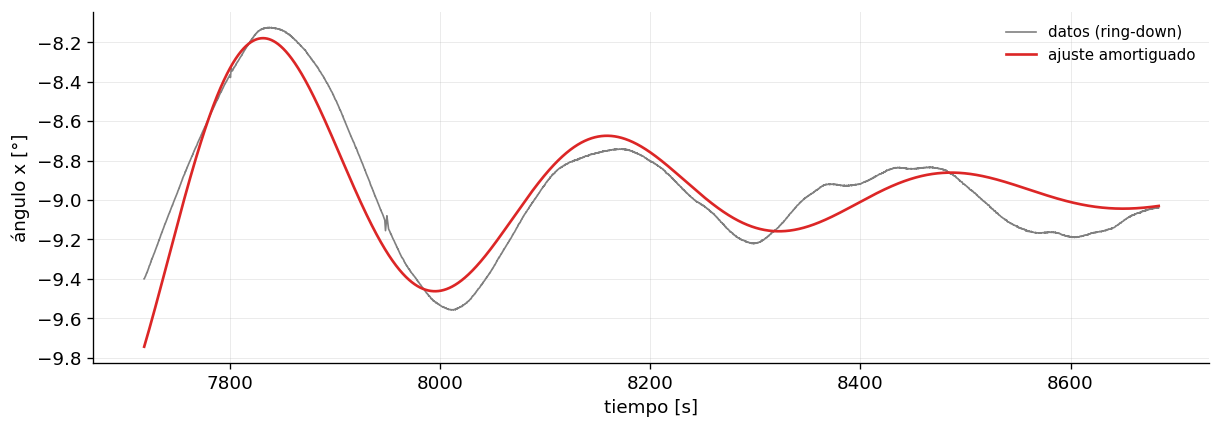

In [187]:
def calcular_kappa(cfg, t, th):
    res, beta_pool = [], {}
    for spec in cfg["kappa_metodos"]:
        if spec["tipo"] == "ajuste":
            dat = load_medicion(spec["fuente"]); thf = a_rad(dat["x_mm"], dat["L_mm"])
            fit = mejor_ventana_ajuste(dat["t"], thf, spec["win"])
            res.append(dict(label=spec["label"], Td=2*np.pi/fit["wd"], beta=fit["beta"], fit=fit,
                            kappa_wd=kappa_de_w0(fit["wd"]), kappa_w0=kappa_de_w0(fit["w0"])))
            beta_pool[spec["label"]] = fit["beta"]
    beta_ap = beta_pool.get(cfg.get("usar_beta_de"), 0.0)
    for spec in cfg["kappa_metodos"]:
        if spec["tipo"] == "periodo":
            wins = [spec["win"]] + ([spec["win2"]] if spec.get("win2") else [])
            Td = float(np.nanmean([periodo_tramo(t, th, w, spec["pico"])[0] for w in wins]))
            wd = 2*np.pi/Td; w0 = np.hypot(wd, beta_ap)
            res.append(dict(label=spec["label"], Td=Td, beta=beta_ap, fit=None,
                            kappa_wd=kappa_de_w0(wd), kappa_w0=kappa_de_w0(w0)))
    return res, beta_ap

metodos, beta_ap = calcular_kappa(cfg, t, th)
df_k = pd.DataFrame([dict(metodo=mm["label"], T_s=round(mm["Td"], 1), beta_1_s=mm["beta"],
                         kappa_sin_corr=mm["kappa_wd"], kappa_corr_beta=mm["kappa_w0"]) for mm in metodos])
pd.options.display.float_format = lambda v: f"{v:.4g}"
display(df_k)

elegido = next(mm for mm in metodos if mm["label"] == cfg["kappa_elegido"])
kappa = elegido["kappa_w0"]; kappa_wd = elegido["kappa_wd"]
kappas = np.array([mm["kappa_w0"] for mm in metodos])
kappa_err = float(np.std(kappas)) if len(kappas) > 1 else kappa*0.02
print(f"\nκ elegida ({elegido['label']}) = {kappa:.4e} N·m/rad  (corrección por β: {100*(kappa/kappa_wd-1):+.1f}%)")
if len(kappas) > 1:
    print(f"dispersión entre métodos: ±{100*kappa_err/np.median(kappas):.1f}%")

# diagnóstico: ¿los imanes cambian el período? (solo si la config lo pide, p.ej. 26)
if cfg.get("comparar_iman"):
    ci = cfg["comparar_iman"]
    Tsin = periodo_tramo(t, th, ci["sin_iman"], ci["pico"])[0]
    Tcon = periodo_tramo(t, th, ci["con_iman"], ci["pico"])[0]
    print(f"\nDiagnóstico imanes (mismo alambre): T sin imán = {Tsin:.0f} s, T con imán = {Tcon:.0f} s "
          f"-> κ_con/κ_sin = {(Tsin/Tcon)**2:.3f}")
    print("  (si difiere de 1, los imanes afectan la frecuencia -> κ con imán sesgada)")

# si hay un ajuste, mostrarlo
fit_show = next((mm["fit"] for mm in metodos if mm["fit"]), None)
if fit_show:
    f = fit_show
    fig, ax = plt.subplots(figsize=(12, 3.8))
    ax.plot(f["t0"]+f["tt"], np.degrees(f["xx"]), lw=1.0, color="0.5", label="datos (ring-down)")
    ax.plot(f["t0"]+f["tt"], np.degrees(f["fit"]), color=C_CM, lw=1.6, label="ajuste amortiguado")
    ax.set_xlabel("tiempo [s]"); ax.set_ylabel("ángulo x [°]"); ax.legend(loc="upper right")
    fig.savefig(FIGS / f"{MEDICION}_kappa_ajuste.png"); plt.show()

## 3) Corrimiento del equilibrio Δθ

El **valor** del equilibrio se toma como la **media directa de la señal** entre los picos marcados (`desde`–`hasta`): como abarca un número entero de ciclos, la oscilación se promedia a cero y usa todas las muestras (robusto al ruido). El **error** y la **evolución** siguen saliendo del análisis por extremos (midlines), más sensible al ruido. Δθ = eq(con masa) − eq(sin masa), corrigiendo deriva con la baseline si hay tramo de retorno.

  ⚠ sin masa: hay 8 max, se pidió hasta 9
  sin masa: eq(media)=-8.9189°  eq(extremos)=-8.9526°  ±0.0193° (error)  deriva -0.07 m°/s
  con masa: eq(media)=-8.9118°  eq(extremos)=-8.9087°  ±0.0273° (error)  deriva +0.05 m°/s

  Δθ (colocar) = +0.0071°   (sin tramo de retorno: no se corrige deriva)
  Δθ = +0.0071 ± 0.0334° = 1.240e-04 rad


,tramo,eq_media_deg,eq_extremos_deg,sesgo_mdeg
0,sin masa,-8.919,-8.953,-33.69
1,con masa,-8.912,-8.909,3.076


  Δθ MEDIA DIRECTA = +0.0071°  -> G =   0.7× CODATA   (el que se usa)
  Δθ por extremos  = +0.0439°  -> G =   4.3× CODATA


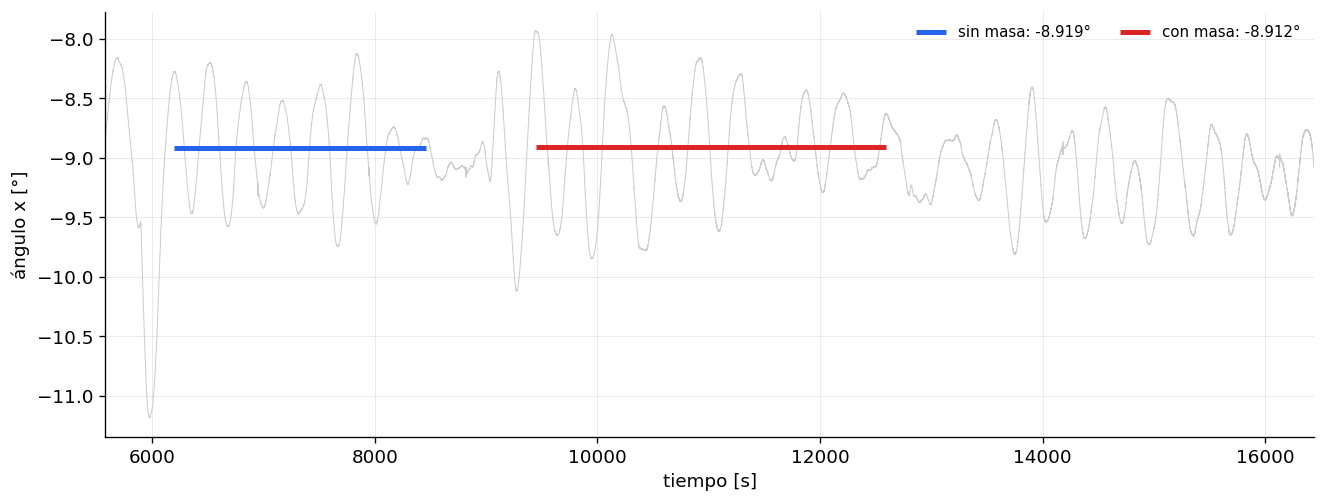

In [188]:
def analizar(sel, etq):
    te, xe, tipo = extremos_tramo(t, th, sel["win"])
    t_lo, t_hi, nd = intervalo_por_picos(te, tipo, sel["pico"], sel["desde"], sel["hasta"])
    if nd < sel["hasta"]: print(f"  ⚠ {etq}: hay {nd} {sel['pico']}, se pidió hasta {sel['hasta']}")
    eq_ext, sem, slope, tm, mids = equilibrio_detrend(te, xe, t_lo, t_hi)   # extremos -> ERROR y evolución
    eq = float(np.mean(th[(t >= t_lo) & (t <= t_hi)]))                       # VALOR para G: media directa entre picos
    msk = (te >= t_lo - 1e-6) & (te <= t_hi + 1e-6)
    print(f"  {etq}: eq(media)={np.degrees(eq):+.4f}°  eq(extremos)={np.degrees(eq_ext):+.4f}°  "
          f"±{np.degrees(sem):.4f}° (error)  deriva {np.degrees(slope)*1000:+.2f} m°/s")
    return dict(eq=eq, eq_ext=eq_ext, sem=sem, t_lo=t_lo, t_hi=t_hi, tc=0.5*(t_lo+t_hi), te_u=te[msk], xe_u=xe[msk])

A = analizar(cfg["sin_masa"], "sin masa")
B = analizar(cfg["con_masa"], "con masa")
C = analizar(cfg["sin_masa_2"], "retorno (sin masa)") if cfg.get("sin_masa_2") else None

if C:   # hay retorno -> corregir deriva con baseline antes/después
    base = float(np.interp(B["tc"], [A["tc"], C["tc"]], [A["eq"], C["eq"]]))
    dtheta = B["eq"] - base
    dtheta_err = np.hypot(B["sem"], 0.5*np.hypot(A["sem"], C["sem"]))
    dth_alt = dict(colocar=B["eq"]-A["eq"], sacar=B["eq"]-C["eq"], corregido=dtheta)
    ret = C["eq"] - A["eq"]
    print(f"\n  retorno eq(ret)-eq(sin) = {np.degrees(ret):+.4f}° ({'vuelve' if abs(ret)<abs(dth_alt['colocar']) else 'NO vuelve: deriva'})")
    print(f"  Δθ colocar={np.degrees(dth_alt['colocar']):+.4f}°  sacar={np.degrees(dth_alt['sacar']):+.4f}°  corregido={np.degrees(dtheta):+.4f}°")
else:   # sin retorno -> placement
    dtheta = B["eq"] - A["eq"]; dtheta_err = np.hypot(A["sem"], B["sem"]); dth_alt = dict(colocar=dtheta)
    print(f"\n  Δθ (colocar) = {np.degrees(dtheta):+.4f}°   (sin tramo de retorno: no se corrige deriva)")
print(f"  Δθ = {np.degrees(dtheta):+.4f} ± {np.degrees(dtheta_err):.4f}° = {dtheta:.3e} rad")

# --- comparación: equilibrio por MEDIA DIRECTA vs por EXTREMOS (cuánto sesga mirar extremos) ---
items_cmp = [("sin masa", A), ("con masa", B)] + ([("retorno", C)] if C else [])
df_eq = pd.DataFrame([dict(tramo=nom, eq_media_deg=np.degrees(R["eq"]), eq_extremos_deg=np.degrees(R["eq_ext"]),
                          sesgo_mdeg=1000*np.degrees(R["eq_ext"] - R["eq"])) for nom, R in items_cmp])
display(df_eq)
if C:
    base_ext = float(np.interp(B["tc"], [A["tc"], C["tc"]], [A["eq_ext"], C["eq_ext"]])); dth_ext = B["eq_ext"] - base_ext
else:
    dth_ext = B["eq_ext"] - A["eq_ext"]
dd = cfg["d_cm_cm"]
print(f"  Δθ MEDIA DIRECTA = {np.degrees(dtheta):+.4f}°  -> G = {G_de(kappa, dtheta, dd)/G_CODATA:5.1f}× CODATA   (el que se usa)")
print(f"  Δθ por extremos  = {np.degrees(dth_ext):+.4f}°  -> G = {G_de(kappa, dth_ext, dd)/G_CODATA:5.1f}× CODATA")

mv = t >= T0
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.plot(t[mv], np.degrees(th[mv]), lw=0.6, color="0.8")
items = [(A, C_SM, "sin masa"), (B, C_CM, "con masa")] + ([(C, C_R, "retorno")] if C else [])
for R, c, lab in items:
    ax.hlines(np.degrees(R["eq"]), R["t_lo"], R["t_hi"], color=c, lw=3, label=f"{lab}: {np.degrees(R['eq']):.3f}°")
if C:
    ax.plot([A["tc"], C["tc"]], np.degrees([A["eq"], C["eq"]]), "--", color="0.45", lw=1.2, label="baseline sin masa")
ax.set_xlim(T0, t[-1]); ax.set_xlabel("tiempo [s]"); ax.set_ylabel("ángulo x [°]"); ax.legend(loc="best", ncol=2)
fig.savefig(FIGS / f"{MEDICION}_corrimiento.png"); plt.show()

## 4) Evolución del valor medio (curva medida + extremos considerados)

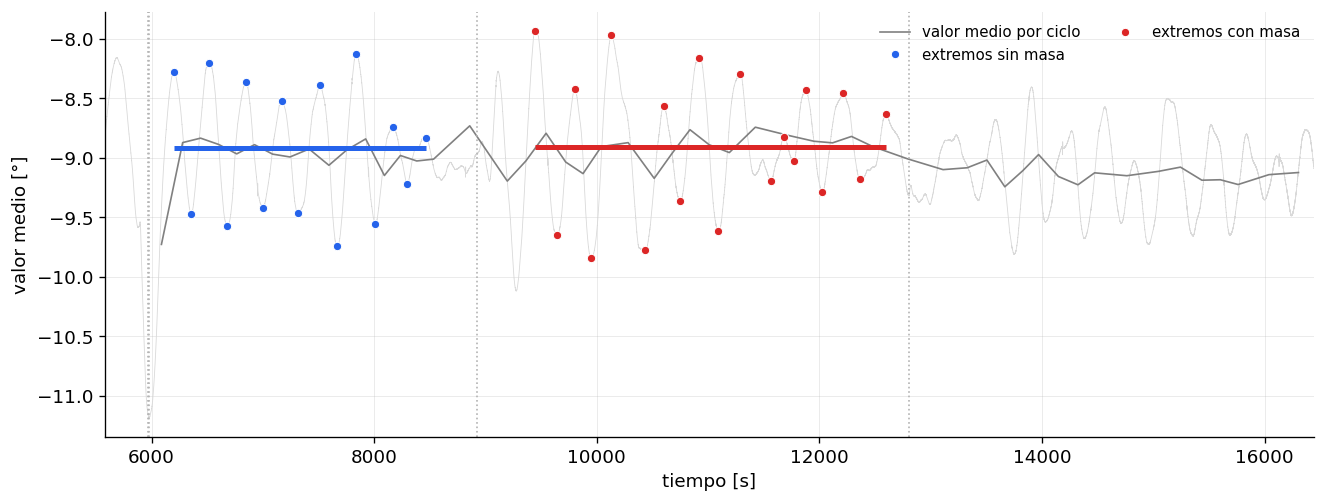

In [189]:
te_all, xe_all, tipo_all = extremos_tramo(t, th, (T0, t[-1]))
tm_all, mid_all = midlines(te_all, xe_all, T0, t[-1])
mv = t >= T0
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.plot(t[mv], np.degrees(th[mv]), lw=0.5, color="0.85")                  # curva medida (de fondo)
ax.plot(tm_all, np.degrees(mid_all), "-", lw=1.0, color="0.5", label="valor medio por ciclo")
items = [(A, C_SM, "sin masa"), (B, C_CM, "con masa")] + ([(C, C_R, "retorno")] if C else [])
for R, c, lab in items:
    ax.plot(R["te_u"], np.degrees(R["xe_u"]), "o", ms=5, color=c, mec="white", mew=0.6, label=f"extremos {lab}")
    ax.hlines(np.degrees(R["eq"]), R["t_lo"], R["t_hi"], color=c, lw=3)
if C:
    ax.plot([A["tc"], C["tc"]], np.degrees([A["eq"], C["eq"]]), "--", color="0.45", lw=1.2, label="baseline")
for e in ev:
    if e >= T0: ax.axvline(e, color="0.7", ls=":", lw=1)
ax.set_xlim(T0, t[-1]); ax.set_xlabel("tiempo [s]"); ax.set_ylabel("valor medio [°]"); ax.legend(loc="best", ncol=2)
fig.savefig(FIGS / f"{MEDICION}_evolucion.png"); plt.show()

## 5) G y cómo achicar el error

In [190]:
d = cfg["d_cm_cm"]
sig = dict(kappa=kappa_err, dtheta=dtheta_err, d=SIG_D)
G0, sG, pct = propagar_G(kappa, dtheta, d, sig)
print(f"[{MEDICION}]  κ = {kappa:.4e} N·m/rad   Δθ = {np.degrees(dtheta):+.4f}°   d = {d*100:.1f} cm")
print(f"G = ({G0:.2e} ± {sG:.1e}) m³ kg⁻¹ s⁻²   ->  {G0/G_CODATA:.1f}× CODATA   (σ {100*sG/G0:.0f}%)")

# G según método de κ (para comparar)
print("\nG/CODATA según el método de κ (con el Δθ elegido):")
for mm in metodos:
    print(f"   {mm['label']:32s}: {G_de(mm['kappa_w0'], dtheta, d)/G_CODATA:5.1f}")
if len(dth_alt) > 1:
    print("G/CODATA según la forma de Δθ (con la κ elegida):")
    for k, v in dth_alt.items():
        print(f"   Δθ {k:10s}: {G_de(kappa, v, d)/G_CODATA:5.1f}")

print("\nCómo achicar el error:")
print(f"  · κ: usar el tramo SIN imanes (como en la 26) evita el sesgo de los imanes; el β corrige {100*(kappa/kappa_wd-1):+.1f}%.")
print(f"  · d (G∝d²): σ_d={SIG_D*100:.1f} cm / {d*100:.0f} cm -> ~{100*2*SIG_D/d:.0f}% de G. Medir d a ±2 mm -> ~{100*2*0.002/d:.0f}%.")
print(f"  · Deriva: cerrar siempre con un tramo de retorno (como T5 en la 30) para corregirla.")
print(f"  Peso en σ(G):", "  ".join(f"{k} {p:.0f}%" for k, p in sorted(pct.items(), key=lambda z:-z[1]) if p > 0.5))

[medicion30]  κ = 3.9215e-04 N·m/rad   Δθ = +0.0071°   d = 6.0 cm
G = (4.62e-11 ± 2.2e-10) m³ kg⁻¹ s⁻²   ->  0.7× CODATA   (σ 470%)

G/CODATA según el método de κ (con el Δθ elegido):
   ajuste ring-down                :   0.7
   período mín                     :   0.7
   período máx                     :   0.7
   período cruces                  :   0.7

Cómo achicar el error:
  · κ: usar el tramo SIN imanes (como en la 26) evita el sesgo de los imanes; el β corrige +2.4%.
  · d (G∝d²): σ_d=0.7 cm / 6 cm -> ~23% de G. Medir d a ±2 mm -> ~7%.
  · Deriva: cerrar siempre con un tramo de retorno (como T5 en la 30) para corregirla.
  Peso en σ(G): dtheta 100%


## 6) Resumen
- **κ** se obtiene distinto según la medición (sin imán en la 26; ajuste de la 27 para la 28; período
  propio + ajuste en la 30) y se corrige por amortiguamiento ($\omega_0^2=\omega_d^2+\beta^2$).
- Los **imanes** pueden sesgar κ (ver diagnóstico en la 26): la κ más limpia es la del tramo **sin imanes**.
- **G** queda limitado por la **deriva** (corregible con tramo de retorno) y por **d** (G∝d²).
- Cambiá `MEDICION` arriba para ver cada caso.